In [2]:
import pandas as pd

In [3]:
sku = pd.read_csv("dim_skus.csv")
stores = pd.read_csv("dim_stores.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")


In [4]:
df = inventory.merge(stores,
                    on="store_id",
                    how="left")


In [5]:
df = df.merge(sku,on="sku_id",how="left")

In [6]:
df.rename(columns={"supplier_id_x": "supplier_id"}, inplace=True)

In [7]:
df = df.merge(suppliers,on="supplier_id",how="left")

In [8]:
df = df.merge(events,on="date",how="left")

In [9]:
df.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,supplier_id_y,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


In [10]:
df.tail()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,supplier_id_y,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
21595,2026-10-26,ST12,SKU060,SUP10,333.1,55,55.0,278.1,142.8,N,...,SUP10,Daily Bakes Supply,"Bakery, Personal Care",0.66,4,0.7,Diwali Week,festival,1.9,1.225
21596,2026-10-27,ST12,SKU060,SUP10,278.1,24,24.0,254.1,142.8,N,...,SUP10,Daily Bakes Supply,"Bakery, Personal Care",0.66,4,0.7,Regular Day,none,1.0,1.000
21597,2026-10-28,ST12,SKU060,SUP10,254.1,17,17.0,237.1,142.8,N,...,SUP10,Daily Bakes Supply,"Bakery, Personal Care",0.66,4,0.7,Regular Day,none,1.0,1.000
21598,2026-10-29,ST12,SKU060,SUP10,237.1,24,24.0,213.1,142.8,N,...,SUP10,Daily Bakes Supply,"Bakery, Personal Care",0.66,4,0.7,Regular Day,none,1.0,1.000
21599,2026-10-30,ST12,SKU060,SUP10,213.1,23,23.0,190.1,142.8,N,...,SUP10,Daily Bakes Supply,"Bakery, Personal Care",0.66,4,0.7,Regular Day,none,1.0,1.000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       21600 non-null  object 
 1   store_id                   21600 non-null  object 
 2   sku_id                     21600 non-null  object 
 3   supplier_id                21600 non-null  object 
 4   opening_stock              21600 non-null  float64
 5   units_demanded             21600 non-null  int64  
 6   units_sold                 21600 non-null  float64
 7   closing_stock              21600 non-null  float64
 8   reorder_point              21600 non-null  float64
 9   reorder_placed             21600 non-null  object 
 10  lead_time_days_expected    21600 non-null  int64  
 11  lead_time_days_actual      1701 non-null   float64
 12  sales_velocity_7d          21600 non-null  float64
 13  days_of_cover              21600 non-null  flo

In [12]:
df.describe()

,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,sqft,opened_year,baseline_daily_orders,unit_price_inr,shelf_life_days,reliability_score,base_lead_time_days,lead_time_variance_days,demand_multiplier_festive,demand_multiplier_other
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,1701.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,16560.00000,21600.000000,21600.000000,21600.000000,21600.000000
mean,127.246588,17.278380,16.753565,125.886069,72.349722,2.600000,3.373604,16.693251,8.137071,2366.916667,2023.583333,367.416667,130.627333,199.316667,0.76000,2.600000,1.366667,1.166667,1.049167
std,146.969344,17.560305,17.255100,146.120852,76.896919,1.496698,1.724393,16.009877,5.153005,1071.738426,1.187345,128.227679,74.092796,210.571213,0.10716,1.496698,0.762178,0.386733,0.107140
min,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,1126.000000,2022.000000,217.000000,31.390000,1.000000,0.63000,1.000000,0.400000,1.000000,1.000000
25%,33.375000,5.750000,5.000000,32.800000,22.750000,1.000000,1.900000,5.570000,4.310000,1472.750000,2022.750000,241.250000,77.930000,4.000000,0.70000,1.000000,0.700000,1.000000,1.000000
50%,75.200000,11.000000,11.000000,74.200000,47.050000,3.000000,3.200000,11.140000,7.540000,1964.000000,2023.500000,327.000000,112.500000,108.000000,0.71000,3.000000,0.800000,1.000000,1.000000
75%,162.125000,23.000000,23.000000,160.000000,90.550000,4.000000,4.800000,23.000000,11.360000,3122.000000,2025.000000,477.500000,162.092500,354.500000,0.91000,4.000000,2.125000,1.000000,1.000000
max,1091.600000,201.000000,201.000000,1091.600000,467.400000,5.000000,8.200000,117.570000,134.850000,4198.000000,2025.000000,580.000000,358.550000,675.000000,0.93000,5.000000,2.800000,2.600000,1.400000


In [13]:
df.columns.tolist()

['date',
 'store_id',
 'sku_id',
 'supplier_id',
 'opening_stock',
 'units_demanded',
 'units_sold',
 'closing_stock',
 'reorder_point',
 'reorder_placed',
 'lead_time_days_expected',
 'lead_time_days_actual',
 'sales_velocity_7d',
 'days_of_cover',
 'is_festival_week',
 'stockout_risk',
 'city',
 'city_display',
 'city_tier',
 'store_size',
 'sqft',
 'opened_year',
 'baseline_daily_orders',
 'sku_name',
 'category',
 'unit_price_inr',
 'shelf_life_days',
 'is_perishable',
 'festive_relevant',
 'popularity_tier',
 'supplier_id_y',
 'supplier_name',
 'categories_supplied',
 'reliability_score',
 'base_lead_time_days',
 'lead_time_variance_days',
 'event_name',
 'event_type',
 'demand_multiplier_festive',
 'demand_multiplier_other']

In [14]:
df.isnull().sum().sort_values(ascending=False)

lead_time_days_actual        19899
reliability_score             5040
date                             0
store_id                         0
opening_stock                    0
units_demanded                   0
sku_id                           0
supplier_id                      0
closing_stock                    0
units_sold                       0
reorder_placed                   0
reorder_point                    0
sales_velocity_7d                0
days_of_cover                    0
is_festival_week                 0
lead_time_days_expected          0
city                             0
city_display                     0
city_tier                        0
store_size                       0
sqft                             0
opened_year                      0
baseline_daily_orders            0
stockout_risk                    0
sku_name                         0
category                         0
shelf_life_days                  0
unit_price_inr                   0
festive_relevant    

In [15]:
df["stockout_risk"].value_counts()

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

In [16]:
df["city_display"].value_counts()

city_display
Mumbai       3600
Delhi        3600
Chennai      3600
Pune         3600
Bengaluru    1800
BENGALURU    1800
hyderabad    1800
Hyderabad    1800
Name: count, dtype: int64

In [17]:
df["city_display"] = df["city_display"].replace({"BENGALURU": "Bengaluru","hyderabad": "Hyderabad"})

In [18]:
df["city_display"].value_counts()

city_display
Mumbai       3600
Bengaluru    3600
Delhi        3600
Pune         3600
Hyderabad    3600
Chennai      3600
Name: count, dtype: int64

In [19]:
df["reliability_score"].isna().sum()

np.int64(5040)

In [20]:
df["reliability_score"] = pd.to_numeric(df["reliability_score"],errors="coerce")

df["reliability_score"] = df["reliability_score"].fillna(df["reliability_score"].median())

In [21]:

df["reorder_gap"] = (
    df["reorder_point"] - df["closing_stock"]
)


print(df[[
    "reorder_point",
    "closing_stock",
    "reorder_gap"
]].tail(10))

# df["reorder_gap"].describe()

       reorder_point  closing_stock  reorder_gap
21590          142.8           72.6         70.2
21591          142.8           31.6        111.2
21592          142.8            0.0        142.8
21593          142.8            0.0        142.8
21594          142.8          333.1       -190.3
21595          142.8          278.1       -135.3
21596          142.8          254.1       -111.3
21597          142.8          237.1        -94.3
21598          142.8          213.1        -70.3
21599          142.8          190.1        -47.3


In [22]:
df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"]
)

print(df[["days_of_cover","lead_time_days_expected","days_of_cover_ratio"]].tail(10))

       days_of_cover  lead_time_days_expected  days_of_cover_ratio
21590           3.14                        4               0.7850
21591           1.27                        4               0.3175
21592           0.00                        4               0.0000
21593           0.00                        4               0.0000
21594          16.58                        4               4.1450
21595          11.54                        4               2.8850
21596          10.19                        4               2.5475
21597           9.84                        4               2.4600
21598           9.84                        4               2.4600
21599           9.31                        4               2.3275


In [23]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by Store → SKU → Date
df = df.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)

# Get previous day's reorder status for each Store-SKU combination
df["previous_reorder"] = (
    df.groupby(["store_id", "sku_id"])["reorder_placed"]
      .shift(1)
)

# Create binary feature
df["is_recent_reorder"] = (
    df["previous_reorder"] == "Y"
).astype(int)

In [24]:
df["is_recent_reorder"].value_counts()

is_recent_reorder
0    19960
1     1640
Name: count, dtype: int64

In [25]:
df["category"].unique()

array(['Fruits & Vegetables', 'Dairy', 'Snacks', 'Beverages',
       'Personal Care', 'Home Care', 'Staples', 'Bakery'], dtype=object)

In [26]:
df["stockout_risk"].value_counts()

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [32]:
X = df.drop(columns=["stockout_risk"])
y = df["stockout_risk"]

In [33]:
df["date"] = pd.to_datetime(df["date"])

In [34]:
df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

In [35]:
drop_columns = [
    "stockout_risk",
    "date",
    "store_id",
    "sku_id",
    "supplier_id"
]

In [36]:
X = df.drop(columns=drop_columns)
y = df["stockout_risk"]

In [37]:
train_df = df[df["date"] <= "2026-10-23"].copy()
test_df = df[df["date"] >= "2026-10-24"].copy()

In [38]:
X_train = train_df.drop(columns=drop_columns)
y_train = train_df["stockout_risk"]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df["stockout_risk"]

In [39]:
print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training shape: (16560, 41)
Testing shape : (5040, 41)

Training target:
stockout_risk
Safe        10992
At-Risk      4060
Imminent     1508
Name: count, dtype: int64

Testing target:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64


In [40]:
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

In [41]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline,numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [42]:
#MODEL1
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

In [43]:
baseline_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [44]:
y_pred_baseline = baseline_model.predict(X_test)

In [45]:
def evaluate_model(model_name, y_true, y_pred):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    imminent_recall = recall_score(
        y_true,
        y_pred,
        labels=["Imminent"],
        average=None,
        zero_division=0
    )[0]

    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Macro Precision    : {precision:.4f}")
    print(f"Macro Recall       : {recall:.4f}")
    print(f"Macro F1           : {f1:.4f}")
    print(f"Imminent Recall    : {imminent_recall:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "Imminent Recall": imminent_recall
    }

In [46]:
baseline_results = evaluate_model(
    "Majority Classifier",
    y_test,
    y_pred_baseline
)

Majority Classifier
Accuracy           : 0.6228
Macro Precision    : 0.2076
Macro Recall       : 0.3333
Macro F1           : 0.2559
Imminent Recall    : 0.0000

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



In [47]:
#MODEL2
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                multi_class="multinomial"
            )
        )
    ]
)

In [48]:
logistic_model.fit(
    X_train,
    y_train
)

C:\Users\omkars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_pred_logistic = logistic_model.predict(
    X_test
)

In [50]:
logistic_results = evaluate_model(
    "Multinomial Logistic Regression",
    y_test,
    y_pred_logistic
)

Multinomial Logistic Regression
Accuracy           : 0.9377
Macro Precision    : 0.9059
Macro Recall       : 0.8930
Macro F1           : 0.8989
Imminent Recall    : 0.8594

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.89      0.82      0.85      1126
    Imminent       0.85      0.86      0.86       775
        Safe       0.97      1.00      0.99      3139

    accuracy                           0.94      5040
   macro avg       0.91      0.89      0.90      5040
weighted avg       0.94      0.94      0.94      5040



In [51]:
#MODEL3
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [52]:
random_forest_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
y_pred_rf = random_forest_model.predict(X_test)

In [54]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
Accuracy           : 0.9327
Macro Precision    : 0.9000
Macro Recall       : 0.8649
Macro F1           : 0.8738
Imminent Recall    : 0.6581

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.80      0.94      0.86      1126
    Imminent       0.91      0.66      0.76       775
        Safe       0.99      1.00      1.00      3139

    accuracy                           0.93      5040
   macro avg       0.90      0.86      0.87      5040
weighted avg       0.94      0.93      0.93      5040



In [55]:
results = pd.DataFrame([
    baseline_results,
    logistic_results,
    rf_results
])

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Imminent Recall
0,Majority Classifier,0.622817,0.207606,0.333333,0.255858,0.000000
1,Multinomial Logistic Regression,0.937698,0.905884,0.893001,0.898886,0.859355
2,Random Forest,0.932738,0.900016,0.864874,0.873836,0.658065


In [56]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Safe", "At-Risk", "Imminent"]
)

# print(cm)

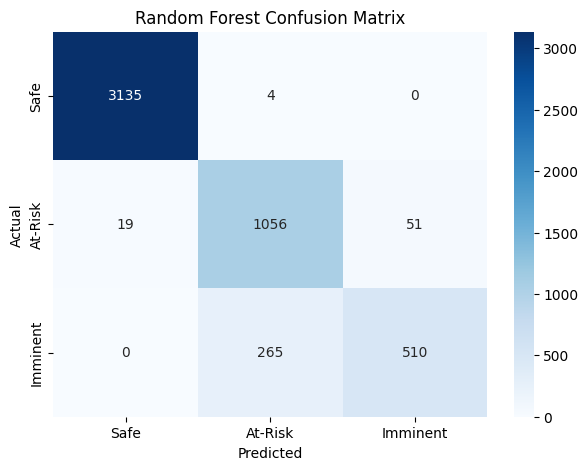

In [57]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe", "At-Risk", "Imminent"],
    yticklabels=["Safe", "At-Risk", "Imminent"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

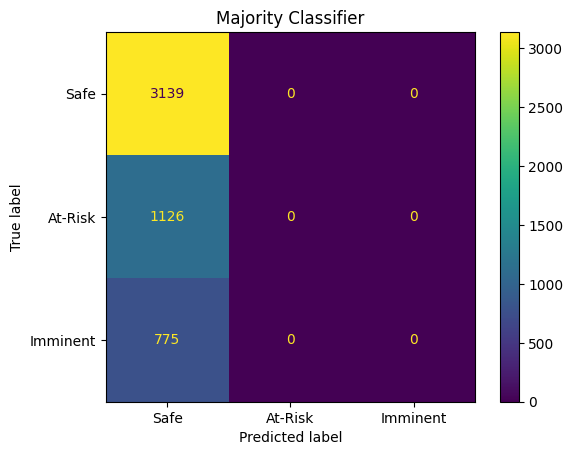

In [58]:
#Visualize Baseline Model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    labels=["Safe", "At-Risk", "Imminent"]
)

plt.title("Majority Classifier")
plt.show()

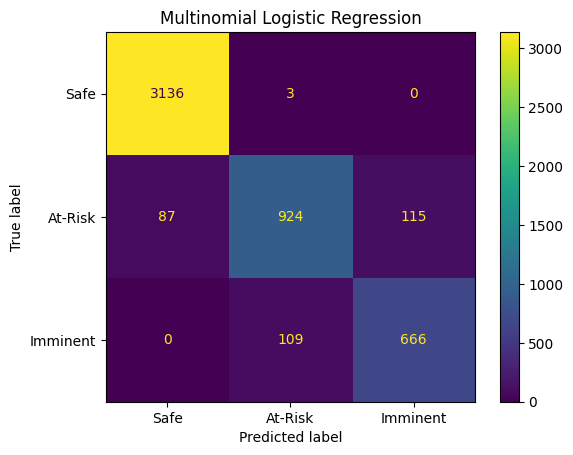

In [59]:
#Lets Visualize Logistic Regression Model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    labels=["Safe", "At-Risk", "Imminent"]
)

plt.title("Multinomial Logistic Regression")
plt.show()

In [60]:
#Detailed Classfication Report for Random Forest
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=["Safe", "At-Risk", "Imminent"]
    )
)

              precision    recall  f1-score   support

        Safe       0.99      1.00      1.00      3139
     At-Risk       0.80      0.94      0.86      1126
    Imminent       0.91      0.66      0.76       775

    accuracy                           0.93      5040
   macro avg       0.90      0.86      0.87      5040
weighted avg       0.94      0.93      0.93      5040



In [61]:
rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

In [62]:
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

In [63]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [64]:
importances = rf_classifier.feature_importances_

In [65]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [66]:
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [67]:
feature_importance_df.head(20)

,Feature,Importance
8,numeric__days_of_cover,0.181645
20,numeric__days_of_cover_ratio,0.167562
19,numeric__reorder_gap,0.162772
3,numeric__closing_stock,0.060782
0,numeric__opening_stock,0.035085
6,numeric__lead_time_days_actual,0.029309
7,numeric__sales_velocity_7d,0.026664
2,numeric__units_sold,0.018575
4,numeric__reorder_point,0.018169
1,numeric__units_demanded,0.017883


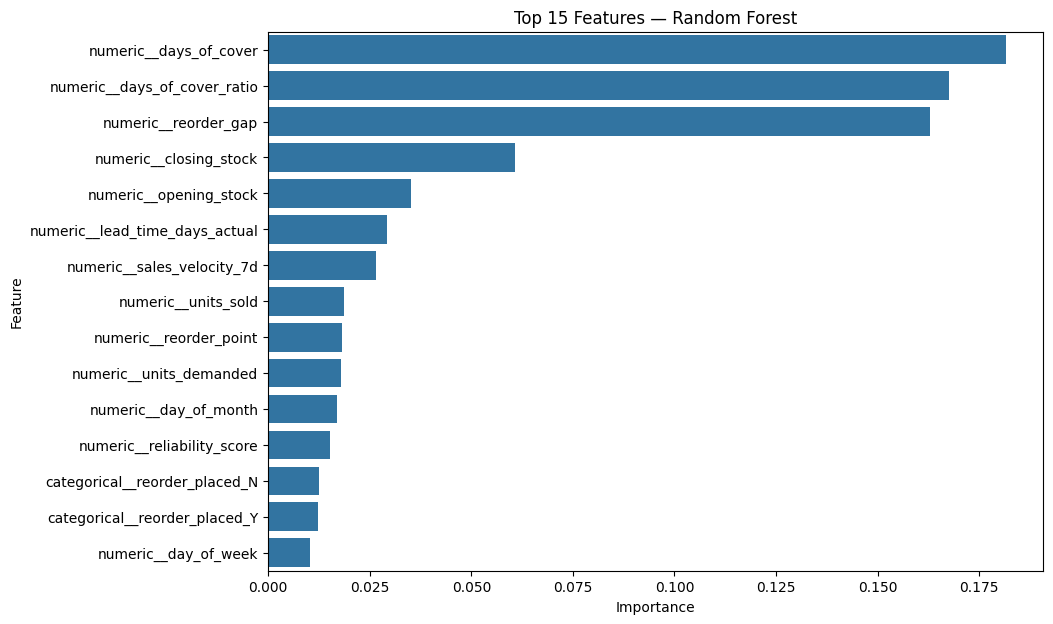

In [68]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [69]:
logistic_classifier = (
    logistic_model
    .named_steps["classifier"]
)

In [70]:
logistic_preprocessor = (
    logistic_model
    .named_steps["preprocessor"]
)

feature_names = (
    logistic_preprocessor
    .get_feature_names_out()
)

In [71]:
coefficients = logistic_classifier.coef_

In [72]:
coef_df = pd.DataFrame(
    coefficients,
    columns=feature_names,
    index=logistic_classifier.classes_
)

coef_df

,numeric__opening_stock,numeric__units_demanded,numeric__units_sold,numeric__closing_stock,numeric__reorder_point,numeric__lead_time_days_expected,numeric__lead_time_days_actual,numeric__sales_velocity_7d,numeric__days_of_cover,numeric__sqft,...,"categorical__categories_supplied_Snacks, Fruits & Vegetables",categorical__categories_supplied_Staples,categorical__event_name_Diwali Week,categorical__event_name_Regular Day,categorical__event_name_Weekend Flash Sale,categorical__event_type_festival,categorical__event_type_none,categorical__event_type_promo,categorical__previous_reorder_N,categorical__previous_reorder_Y
At-Risk,-0.176715,-1.03579,1.004757,-0.345245,0.289124,0.003003,-0.121074,0.185915,-1.260544,-0.090731,...,0.059694,-0.068538,0.047470,-0.151197,0.033904,0.047470,-0.151197,0.033904,-0.008113,-0.061710
Imminent,-0.563099,1.09915,-0.942849,-0.342417,-0.382376,0.198651,0.514080,0.946101,-7.705953,0.061098,...,0.041374,-0.178765,-0.587136,-0.451720,-0.158623,-0.587136,-0.451720,-0.158623,-1.081364,-0.116114
Safe,0.739814,-0.06336,-0.061908,0.687662,0.093253,-0.201655,-0.393006,-1.132016,8.966497,0.029634,...,-0.101068,0.247303,0.539666,0.602917,0.124719,0.539666,0.602917,0.124719,1.089477,0.177824


In [73]:
imminent_results = []

for model_name, y_pred in [
    ("Baseline", y_pred_baseline),
    ("Logistic Regression", y_pred_logistic),
    ("Random Forest", y_pred_rf)
]:

    imminent_precision = precision_score(
        y_test,
        y_pred,
        labels=["Imminent"],
        average=None,
        zero_division=0
    )[0]

    imminent_recall = recall_score(
        y_test,
        y_pred,
        labels=["Imminent"],
        average=None,
        zero_division=0
    )[0]

    imminent_f1 = f1_score(
        y_test,
        y_pred,
        labels=["Imminent"],
        average=None,
        zero_division=0
    )[0]

    imminent_results.append({
        "Model": model_name,
        "Imminent Precision": imminent_precision,
        "Imminent Recall": imminent_recall,
        "Imminent F1": imminent_f1
    })

imminent_results_df = pd.DataFrame(
    imminent_results
)

imminent_results_df

,Model,Imminent Precision,Imminent Recall,Imminent F1
0,Baseline,0.000000,0.000000,0.000000
1,Logistic Regression,0.852753,0.859355,0.856041
2,Random Forest,0.909091,0.658065,0.763473


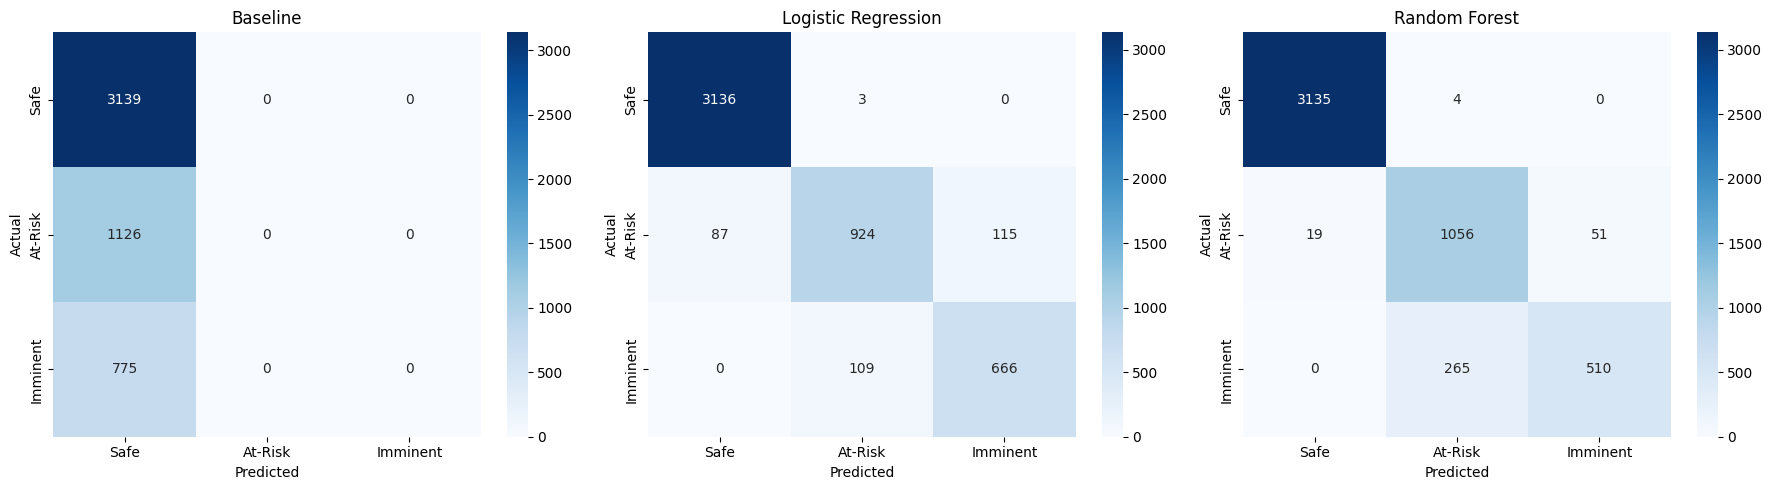

In [74]:
models_predictions = {
    "Baseline": y_pred_baseline,
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["Safe", "At-Risk", "Imminent"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Safe", "At-Risk", "Imminent"],
        yticklabels=["Safe", "At-Risk", "Imminent"],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [75]:
feature_names = X_train.columns

print("Number of features:", len(feature_names))
print(feature_names.tolist())

Number of features: 41
['opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other', 'reorder_gap', 'days_of_cover_ratio', 'previous_reorder', 'is_recent_reorder', 'day_of_month', 'day_of_week']


In [77]:
rf_model = random_forest_model.named_steps["classifier"]

print("X_train columns:", X_train.shape[1])
print("Feature names:", len(X_train.columns))
print("RF importances:", len(rf_model.feature_importances_))

X_train columns: 41
Feature names: 41
RF importances: 164


In [79]:
print(X_train.dtypes.tolist())

[dtype('float64'), dtype('int64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('O'), dtype('int64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('float64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('int64'), dtype('float64'), dtype('O'), dtype('O'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('O'), dtype('int64'), dtype('int32'), dtype('int32')]


In [80]:
rf_model = random_forest_model.named_steps["classifier"]

print("RF expects:", rf_model.n_features_in_)
print("RF importance count:", len(rf_model.feature_importances_))

RF expects: 164
RF importance count: 164


In [81]:
print(random_forest_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['opening_stock',
                                                   'units_demanded',
                                                   'units_sold',
                                                   'closing_stock',
                                                   'reorder_point',
                                                   'lead_time_days_expected',
                                                   'lead_time_days_actual',
                                                   'sales_velocity_7d

In [82]:
preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 164


In [83]:
rf_model = random_forest_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(20)

,Feature,Importance
0,numeric__days_of_cover,0.181645
1,numeric__days_of_cover_ratio,0.167562
2,numeric__reorder_gap,0.162772
3,numeric__closing_stock,0.060782
4,numeric__opening_stock,0.035085
5,numeric__lead_time_days_actual,0.029309
6,numeric__sales_velocity_7d,0.026664
7,numeric__units_sold,0.018575
8,numeric__reorder_point,0.018169
9,numeric__units_demanded,0.017883


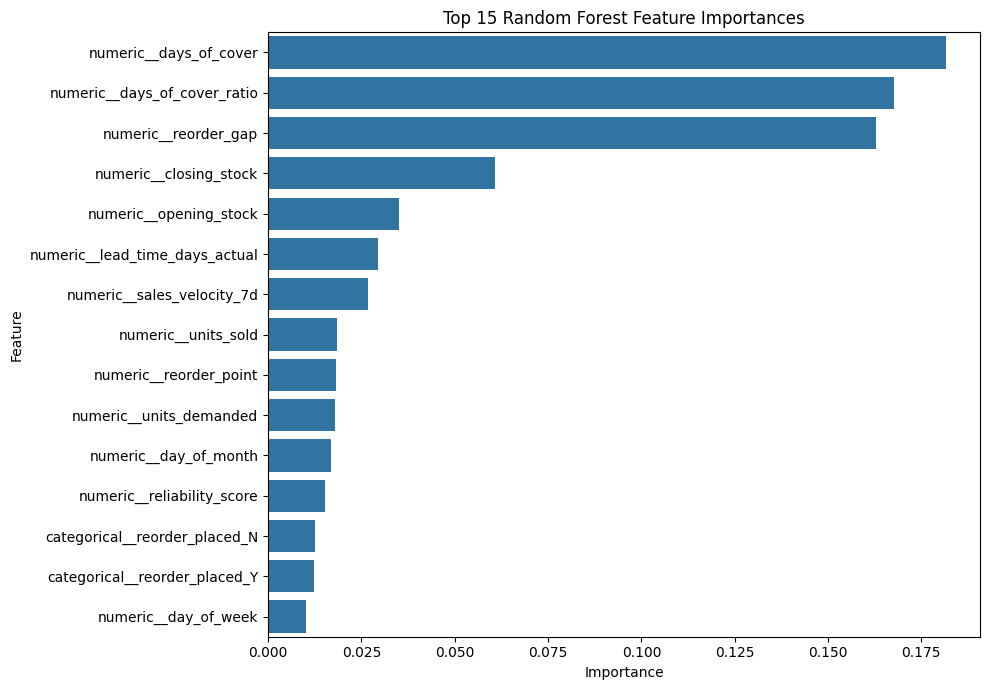

In [84]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [85]:
logistic_preprocessor = logistic_model.named_steps["preprocessor"]

logistic_feature_names = (
    logistic_preprocessor.get_feature_names_out()
)

print("Number of features:",
      len(logistic_feature_names))

Number of features: 164


In [86]:
logistic_classifier = logistic_model.named_steps["classifier"]

print("Number of classes:",
      len(logistic_classifier.classes_))

print("Classes:",
      logistic_classifier.classes_)

print("Coefficient shape:",
      logistic_classifier.coef_.shape)

Number of classes: 3
Classes: ['At-Risk' 'Imminent' 'Safe']
Coefficient shape: (3, 164)


In [87]:
logistic_coefficients = pd.DataFrame(
    logistic_classifier.coef_,
    columns=logistic_feature_names,
    index=logistic_classifier.classes_
)

logistic_coefficients

,numeric__opening_stock,numeric__units_demanded,numeric__units_sold,numeric__closing_stock,numeric__reorder_point,numeric__lead_time_days_expected,numeric__lead_time_days_actual,numeric__sales_velocity_7d,numeric__days_of_cover,numeric__sqft,...,"categorical__categories_supplied_Snacks, Fruits & Vegetables",categorical__categories_supplied_Staples,categorical__event_name_Diwali Week,categorical__event_name_Regular Day,categorical__event_name_Weekend Flash Sale,categorical__event_type_festival,categorical__event_type_none,categorical__event_type_promo,categorical__previous_reorder_N,categorical__previous_reorder_Y
At-Risk,-0.176715,-1.03579,1.004757,-0.345245,0.289124,0.003003,-0.121074,0.185915,-1.260544,-0.090731,...,0.059694,-0.068538,0.047470,-0.151197,0.033904,0.047470,-0.151197,0.033904,-0.008113,-0.061710
Imminent,-0.563099,1.09915,-0.942849,-0.342417,-0.382376,0.198651,0.514080,0.946101,-7.705953,0.061098,...,0.041374,-0.178765,-0.587136,-0.451720,-0.158623,-0.587136,-0.451720,-0.158623,-1.081364,-0.116114
Safe,0.739814,-0.06336,-0.061908,0.687662,0.093253,-0.201655,-0.393006,-1.132016,8.966497,0.029634,...,-0.101068,0.247303,0.539666,0.602917,0.124719,0.539666,0.602917,0.124719,1.089477,0.177824


In [88]:
imminent_coefficients = (
    logistic_coefficients
    .loc["Imminent"]
    .sort_values(ascending=False)
)

imminent_coefficients.head(15)

numeric__units_demanded                        1.099150
numeric__sales_velocity_7d                     0.946101
categorical__sku_name_Laundry Detergent 1kg    0.932972
numeric__baseline_daily_orders                 0.521640
numeric__lead_time_days_actual                 0.514080
categorical__sku_name_Toilet Cleaner 500ml     0.500042
categorical__sku_name_Namkeen Mix 200g         0.405732
categorical__sku_name_Cup Cakes 4pc            0.397891
categorical__sku_name_Energy Drink 250ml       0.394645
categorical__sku_name_Salted Peanuts 200g      0.376857
categorical__sku_name_Cola 750ml               0.373362
categorical__sku_name_Bar Soap 125g            0.360804
categorical__sku_name_Apple 1kg                0.316766
categorical__store_size_Small                  0.314416
categorical__sku_name_Ghee 500ml               0.314309
Name: Imminent, dtype: float64

In [89]:
imminent_coefficients.tail(15)

categorical__event_type_festival               -0.587136
categorical__event_name_Diwali Week            -0.587136
categorical__sku_name_Air Freshener            -0.629400
categorical__is_festival_week_Y                -0.636993
categorical__sku_name_Choco Cookies 150g       -0.657519
categorical__sku_name_Dish Wash Liquid 500ml   -0.732985
categorical__festive_relevant_N                -0.751729
categorical__is_perishable_N                   -0.806494
numeric__units_sold                            -0.942849
categorical__store_size_Large                  -1.012914
categorical__previous_reorder_N                -1.081364
categorical__city_tier_Tier1                   -1.197479
categorical__reorder_placed_N                  -1.288544
numeric__days_of_cover_ratio                   -5.989192
numeric__days_of_cover                         -7.705953
Name: Imminent, dtype: float64

In [90]:
model_comparison = pd.DataFrame([
    baseline_results,
    logistic_results,
    rf_results
])

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Imminent Recall
0,Majority Classifier,0.622817,0.207606,0.333333,0.255858,0.000000
1,Multinomial Logistic Regression,0.937698,0.905884,0.893001,0.898886,0.859355
2,Random Forest,0.932738,0.900016,0.864874,0.873836,0.658065


In [92]:
imminent_results

[{'Model': 'Baseline',
  'Imminent Precision': np.float64(0.0),
  'Imminent Recall': np.float64(0.0),
  'Imminent F1': np.float64(0.0)},
 {'Model': 'Logistic Regression',
  'Imminent Precision': np.float64(0.852752880921895),
  'Imminent Recall': np.float64(0.8593548387096774),
  'Imminent F1': np.float64(0.8560411311053985)},
 {'Model': 'Random Forest',
  'Imminent Precision': np.float64(0.9090909090909091),
  'Imminent Recall': np.float64(0.6580645161290323),
  'Imminent F1': np.float64(0.7634730538922155)}]

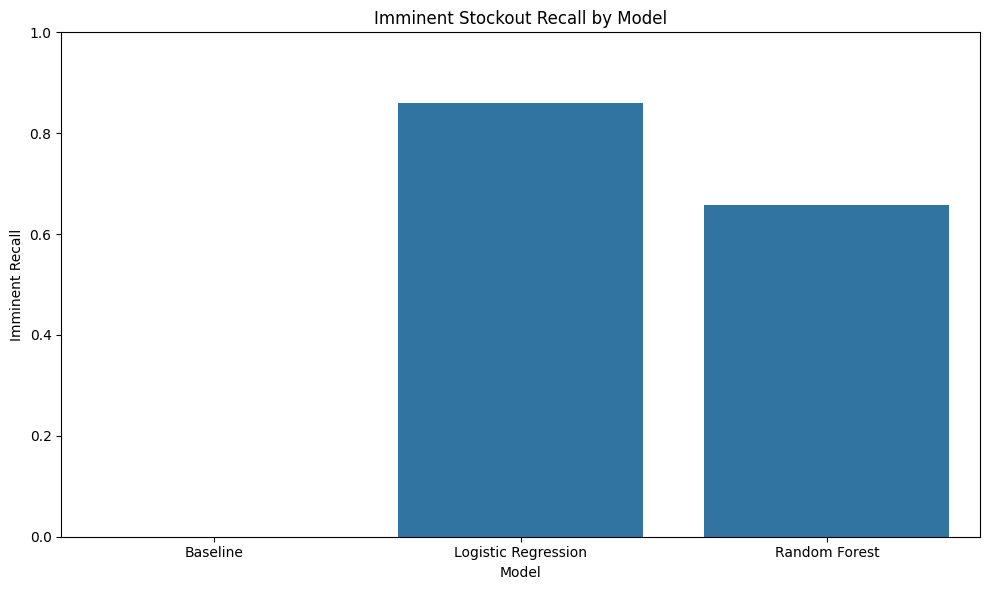

In [93]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=imminent_results_df,
    x="Model",
    y="Imminent Recall"
)

plt.title("Imminent Stockout Recall by Model")
plt.xlabel("Model")
plt.ylabel("Imminent Recall")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

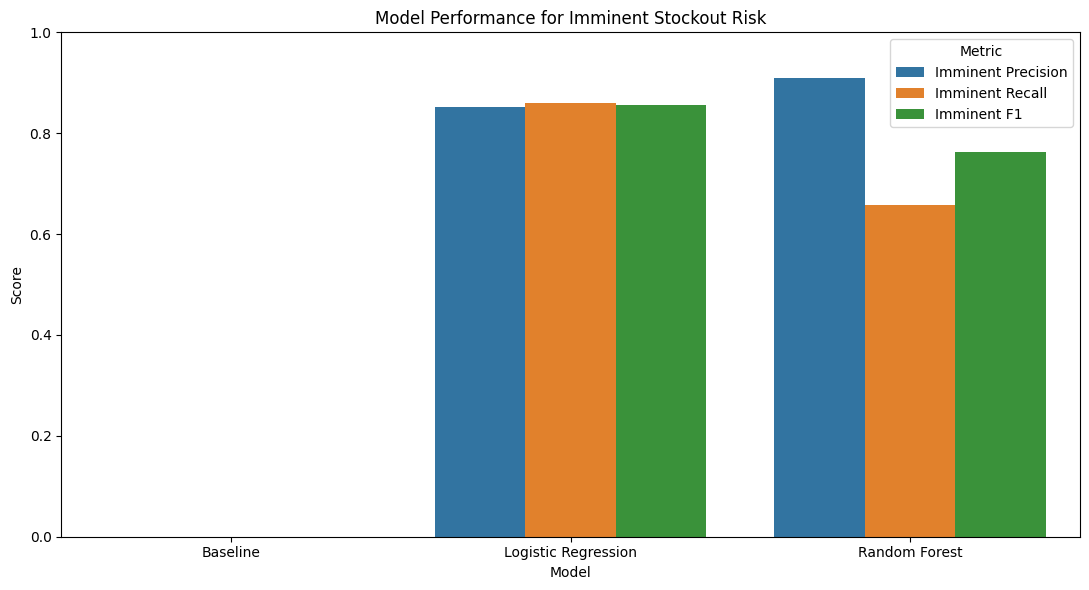

In [94]:
imminent_plot_df = imminent_results_df.melt(
    id_vars="Model",
    value_vars=[
        "Imminent Precision",
        "Imminent Recall",
        "Imminent F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=imminent_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance for Imminent Stockout Risk")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [95]:
#Overall stockout risk distribution
risk_distribution = (
    df["stockout_risk"]
    .value_counts()
    .rename_axis("Risk")
    .reset_index(name="Count")
)

risk_distribution["Percentage"] = (
    risk_distribution["Count"]
    / risk_distribution["Count"].sum()
    * 100
)

risk_distribution

,Risk,Count,Percentage
0,Safe,14131,65.421296
1,At-Risk,5186,24.009259
2,Imminent,2283,10.569444


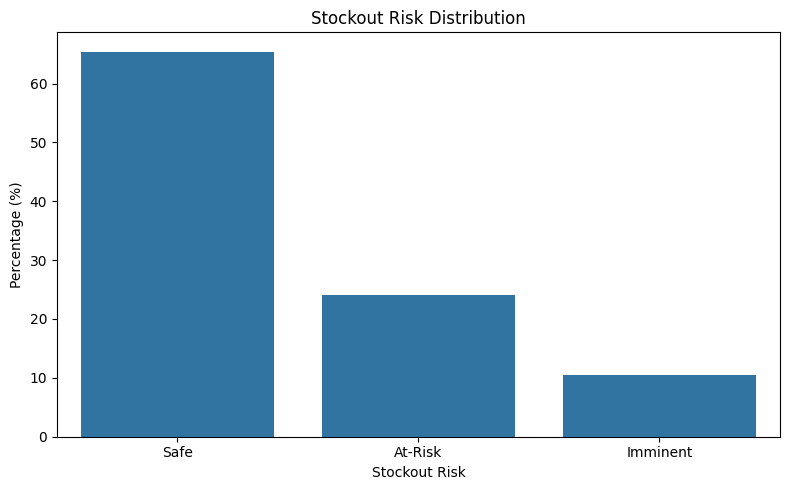

In [96]:


plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_distribution,
    x="Risk",
    y="Percentage"
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

In [97]:
#Festival vs Non-Festival
festival_analysis = (
    df.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reset_index(name="Imminent_Rate")
)

festival_analysis

,is_festival_week,Imminent_Rate
0,N,9.511633
1,Y,23.309179


In [98]:
festival_analysis["Period"] = festival_analysis[
    "is_festival_week"
].map({
    "Y": "Festival",
    "N": "Non-Festival",
    1: "Festival",
    0: "Non-Festival"
})

festival_analysis

,is_festival_week,Imminent_Rate,Period
0,N,9.511633,Non-Festival
1,Y,23.309179,Festival


In [99]:
df["is_festival_week"].value_counts(dropna=False)

is_festival_week
N    19944
Y     1656
Name: count, dtype: int64

In [100]:
#Supplier Reliability
df["reliability_group"] = pd.cut(
    df["reliability_score"],
    bins=[-np.inf, 0.75, 0.85, np.inf],
    labels=["<0.75", "0.75–0.85", ">=0.85"]
)

In [101]:
supplier_reliability_analysis = (
    df.groupby("reliability_group", observed=True)["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reset_index(name="Imminent_Rate")
)

supplier_reliability_analysis

,reliability_group,Imminent_Rate
0,<0.75,13.074495
1,0.75–0.85,3.263889
2,>=0.85,3.819444


In [102]:
#Perishable vs non-perishable
perishable_analysis = (
    df.groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reset_index(name="Imminent_Rate")
)

perishable_analysis

,is_perishable,Imminent_Rate
0,N,9.298246
1,Y,12.765152


In [103]:
df["is_perishable"].value_counts(dropna=False)

is_perishable
N    13680
Y     7920
Name: count, dtype: int64

In [104]:
#Product Category Analysis
category_analysis = (
    df.groupby("category")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reset_index(name="Imminent_Rate")
    .sort_values("Imminent_Rate", ascending=False)
)

category_analysis

,category,Imminent_Rate
0,Bakery,26.111111
1,Beverages,14.548611
6,Snacks,10.185185
4,Home Care,8.518519
3,Fruits & Vegetables,7.932099
2,Dairy,7.539683
5,Personal Care,6.785714
7,Staples,5.833333


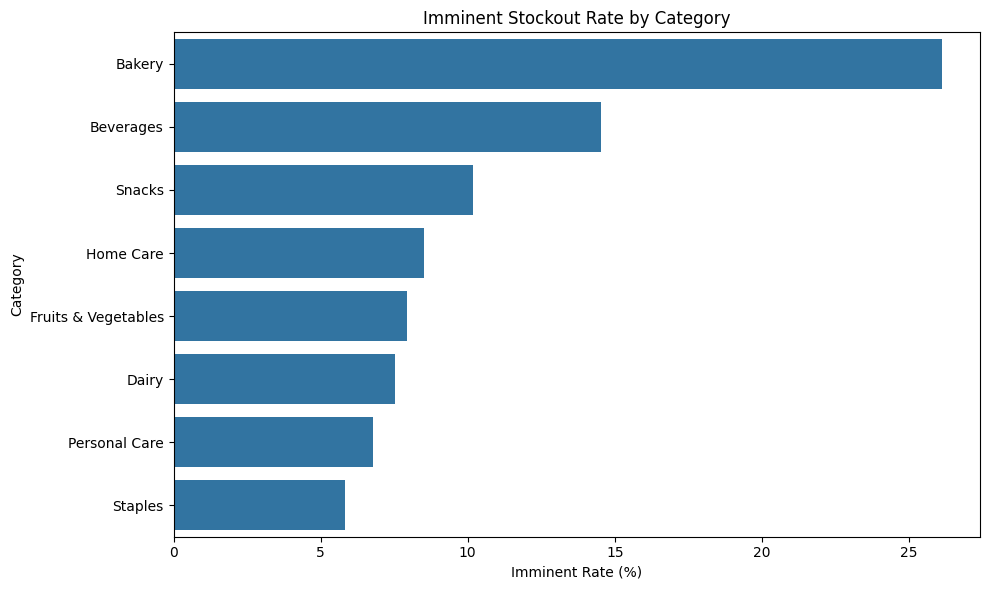

In [105]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis,
    x="Imminent_Rate",
    y="category"
)

plt.title("Imminent Stockout Rate by Category")
plt.xlabel("Imminent Rate (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [106]:
#Store Analysis
store_analysis = (
    df.groupby(["store_id", "city_display"])["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reset_index(name="Imminent_Rate")
    .sort_values("Imminent_Rate", ascending=False)
)

store_analysis

,store_id,city_display,Imminent_Rate
10,ST11,Chennai,13.055556
9,ST10,Hyderabad,11.388889
1,ST02,Mumbai,11.277778
7,ST08,Pune,11.222222
5,ST06,Delhi,10.944444
8,ST09,Hyderabad,10.722222
0,ST01,Mumbai,10.444444
11,ST12,Chennai,10.111111
4,ST05,Delhi,10.055556
6,ST07,Pune,9.944444


In [109]:
risk_feature_analysis = (
    df.groupby("stockout_risk")[
        [
            "days_of_cover",
            "days_of_cover_ratio",
            "reorder_gap",
            "sales_velocity_7d",
            "closing_stock"
        ]
    ]
    .mean()
    .reindex(["Safe", "At-Risk", "Imminent"])
)

risk_feature_analysis

,days_of_cover,days_of_cover_ratio,reorder_gap,sales_velocity_7d,closing_stock
stockout_risk,,,,,
Safe,10.636469,6.459418,-92.379655,15.969428,159.537648
At-Risk,4.051568,1.662209,10.797898,18.294383,74.320748
Imminent,1.947157,0.675387,40.750723,17.536386,34.728515


In [110]:
#Final Wrapping up the project
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))

Dataset shape: (21600, 47)

Columns:
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other', 'reorder_gap', 'days_of_cover_ratio', 'previous_reorder', 'is_recent_reorder', 'day_of_month', 'day_of_week', 'reliability_group']

Missing values:
lead_time_days_actual      19899
previous_reorder             720
store_id                       0
supplier_id   

In [111]:
required_features = [
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "day_of_week",
    "sales_velocity_7d",
    "days_of_cover",
    "lead_time_days_expected",
    "reliability_score"
]

print("Feature verification:")
for feature in required_features:
    print(
        f"{feature}:",
        "✓ Present" if feature in df.columns else "✗ MISSING"
    )

Feature verification:
reorder_gap: ✓ Present
days_of_cover_ratio: ✓ Present
day_of_month: ✓ Present
day_of_week: ✓ Present
sales_velocity_7d: ✓ Present
days_of_cover: ✓ Present
lead_time_days_expected: ✓ Present
reliability_score: ✓ Present


In [112]:
print(df["stockout_risk"].value_counts())

print("\nTarget percentages:")
print(
    df["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Target percentages:
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


In [113]:
print("Training period:")
print(train_df["date"].min())
print(train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min())
print(test_df["date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows :", len(test_df))

Training period:
2026-10-01 00:00:00
2026-10-23 00:00:00

Testing period:
2026-10-24 00:00:00
2026-10-30 00:00:00

Training rows: 16560
Testing rows : 5040


In [114]:
print("Train dates after test start:",
      (train_df["date"] >= pd.Timestamp("2026-10-24")).sum())

print("Test dates before train end:",
      (test_df["date"] <= pd.Timestamp("2026-10-23")).sum())

Train dates after test start: 0
Test dates before train end: 0


In [115]:
print("Target in X_train:", "stockout_risk" in X_train.columns)
print("Target in X_test :", "stockout_risk" in X_test.columns)

Target in X_train: False
Target in X_test : False


In [116]:

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Imminent Recall
0,Majority Classifier,0.622817,0.207606,0.333333,0.255858,0.000000
1,Multinomial Logistic Regression,0.937698,0.905884,0.893001,0.898886,0.859355
2,Random Forest,0.932738,0.900016,0.864874,0.873836,0.658065


In [118]:
imminent_results_df

,Model,Imminent Precision,Imminent Recall,Imminent F1
0,Baseline,0.000000,0.000000,0.000000
1,Logistic Regression,0.852753,0.859355,0.856041
2,Random Forest,0.909091,0.658065,0.763473


In [119]:
print(df[[
    "days_of_cover",
    "lead_time_days_expected",
    "days_of_cover_ratio",
    "reorder_point",
    "closing_stock",
    "stockout_risk"
]].head(10))

   days_of_cover  lead_time_days_expected  days_of_cover_ratio  reorder_point  \
0           9.66                        1                 9.66           36.4   
1          10.79                        1                10.79           36.4   
2           8.99                        1                 8.99           36.4   
3           8.79                        1                 8.79           36.4   
4           8.55                        1                 8.55           36.4   
5           7.52                        1                 7.52           36.4   
6           6.99                        1                 6.99           36.4   
7           6.01                        1                 6.01           36.4   
8           4.81                        1                 4.81           36.4   
9           3.76                        1                 3.76           36.4   

   closing_stock stockout_risk  
0          144.9          Safe  
1          134.9          Safe  
2        

In [120]:
print(df[[
    "days_of_cover",
    "days_of_cover_ratio",
    "reorder_gap"
]].describe())

       days_of_cover  days_of_cover_ratio   reorder_gap
count   21600.000000         21600.000000  21600.000000
mean        8.137071             4.696304    -53.536347
std         5.153005             4.491873    104.712819
min         0.000000             0.000000   -810.000000
25%         4.310000             1.628000    -78.500000
50%         7.540000             3.143333    -26.300000
75%        11.360000             6.480000      0.000000
max       134.850000           134.850000    393.500000


In [121]:
print(df["previous_reorder"].value_counts(dropna=False))

previous_reorder
N      19240
Y       1640
NaN      720
Name: count, dtype: int64


In [122]:
print(
    df[df["previous_reorder"].isna()][
        ["date", "store_id", "sku_id", "reorder_placed", "previous_reorder"]
    ].head(20)
)

          date store_id  sku_id reorder_placed previous_reorder
0   2026-10-01     ST01  SKU001              N              NaN
30  2026-10-01     ST01  SKU002              N              NaN
60  2026-10-01     ST01  SKU003              Y              NaN
90  2026-10-01     ST01  SKU004              Y              NaN
120 2026-10-01     ST01  SKU005              N              NaN
150 2026-10-01     ST01  SKU006              N              NaN
180 2026-10-01     ST01  SKU007              N              NaN
210 2026-10-01     ST01  SKU008              N              NaN
240 2026-10-01     ST01  SKU009              N              NaN
270 2026-10-01     ST01  SKU010              N              NaN
300 2026-10-01     ST01  SKU011              N              NaN
330 2026-10-01     ST01  SKU012              N              NaN
360 2026-10-01     ST01  SKU013              N              NaN
390 2026-10-01     ST01  SKU014              N              NaN
420 2026-10-01     ST01  SKU015         

In [129]:
print(df["previous_reorder"].value_counts(dropna=False))

print(df[[
    "closing_stock",
    "sales_velocity_7d",
    "days_of_cover",
    "lead_time_days_expected"
]].head(10))

df["days_of_cover"] = (
    df["closing_stock"] / df["sales_velocity_7d"]
)

df["days_of_cover"].head(100)

previous_reorder
N      19240
Y       1640
NaN      720
Name: count, dtype: int64
   closing_stock  sales_velocity_7d  days_of_cover  lead_time_days_expected
0          144.9              15.00       9.660000                        1
1          134.9              12.50      10.792000                        1
2          119.9              13.33       8.994749                        1
3          109.9              12.50       8.792000                        1
4          100.9              11.80       8.550847                        1
5           88.9              11.83       7.514793                        1
6           79.9              11.43       6.990376                        1
7           66.9              11.14       6.005386                        1
8           54.9              11.43       4.803150                        1
9           41.9              11.14       3.761221                        1


0      9.660000
1     10.792000
2      8.994749
3      8.792000
4      8.550847
        ...    
95    13.781764
96    12.710638
97    12.350632
98    11.622827
99    11.427907
Name: days_of_cover, Length: 100, dtype: float64

In [130]:
df["days_of_cover"].head(100)

0      9.660000
1     10.792000
2      8.994749
3      8.792000
4      8.550847
        ...    
95    13.781764
96    12.710638
97    12.350632
98    11.622827
99    11.427907
Name: days_of_cover, Length: 100, dtype: float64

In [131]:
final_results = pd.merge(
    model_comparison,
    imminent_results_df,
    on="Model",
    how="left"
)

final_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Imminent Recall_x,Imminent Precision,Imminent Recall_y,Imminent F1
0,Majority Classifier,0.622817,0.207606,0.333333,0.255858,0.000000,NaN,NaN,NaN
1,Multinomial Logistic Regression,0.937698,0.905884,0.893001,0.898886,0.859355,NaN,NaN,NaN
2,Random Forest,0.932738,0.900016,0.864874,0.873836,0.658065,0.909091,0.658065,0.763473


In [132]:
final_results = imminent_results_df.merge(
    model_comparison[
        [
            "Model",
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1"
        ]
    ],
    on="Model",
    how="left"
)

final_results = final_results[
    [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Imminent Precision",
        "Imminent Recall",
        "Imminent F1"
    ]
]

final_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Imminent Precision,Imminent Recall,Imminent F1
0,Baseline,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,Logistic Regression,NaN,NaN,NaN,NaN,0.852753,0.859355,0.856041
2,Random Forest,0.932738,0.900016,0.864874,0.873836,0.909091,0.658065,0.763473


In [134]:
df.columns.tolist()

['date',
 'store_id',
 'sku_id',
 'supplier_id',
 'opening_stock',
 'units_demanded',
 'units_sold',
 'closing_stock',
 'reorder_point',
 'reorder_placed',
 'lead_time_days_expected',
 'lead_time_days_actual',
 'sales_velocity_7d',
 'days_of_cover',
 'is_festival_week',
 'stockout_risk',
 'city',
 'city_display',
 'city_tier',
 'store_size',
 'sqft',
 'opened_year',
 'baseline_daily_orders',
 'sku_name',
 'category',
 'unit_price_inr',
 'shelf_life_days',
 'is_perishable',
 'festive_relevant',
 'popularity_tier',
 'supplier_id_y',
 'supplier_name',
 'categories_supplied',
 'reliability_score',
 'base_lead_time_days',
 'lead_time_variance_days',
 'event_name',
 'event_type',
 'demand_multiplier_festive',
 'demand_multiplier_other',
 'reorder_gap',
 'days_of_cover_ratio',
 'previous_reorder',
 'is_recent_reorder',
 'day_of_month',
 'day_of_week',
 'reliability_group']

In [141]:
df[[
    "reorder_point",
    "reorder_gap",
    "closing_stock",
    "days_of_cover",
    "lead_time_variance_days",
    "days_of_cover_ratio"
]].describe()

C:\Users\omkars\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,reorder_point,reorder_gap,closing_stock,days_of_cover,lead_time_variance_days,days_of_cover_ratio
count,21600.000000,21600.000000,21600.000000,2.160000e+04,21600.000000,21600.000000
mean,72.349722,-53.536347,125.886069,inf,1.366667,4.696304
std,76.896919,104.712819,146.120852,NaN,0.762178,4.491873
min,3.000000,-810.000000,0.000000,0.000000e+00,0.400000,0.000000
25%,22.750000,-78.500000,32.800000,4.312950e+00,0.700000,1.628000
50%,47.050000,-26.300000,74.200000,7.543860e+00,0.800000,3.143333
75%,90.550000,0.000000,160.000000,1.135649e+01,2.125000,6.480000
max,467.400000,393.500000,1091.600000,inf,2.800000,134.850000
